In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay,f1_score,accuracy_score,precision_score,recall_score,classification_report,confusion_matrix

In [2]:
df=pd.read_csv('social_network_ads.csv')

In [3]:
df.shape

(400, 5)

In [4]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [7]:
int(df.duplicated().sum())

0

In [8]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [10]:
df=df.drop(columns=["User ID"])

In [11]:
df["Gender"].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [12]:
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])

In [13]:
df["Gender"].value_counts()

Gender
0    204
1    196
Name: count, dtype: int64

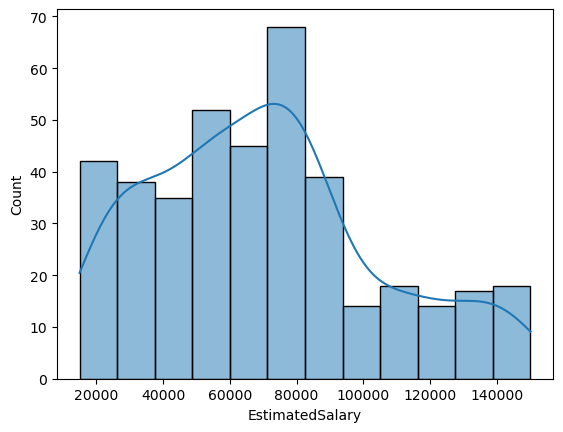

In [14]:
sns.histplot(data=df["EstimatedSalary"],kde=True)
plt.show()

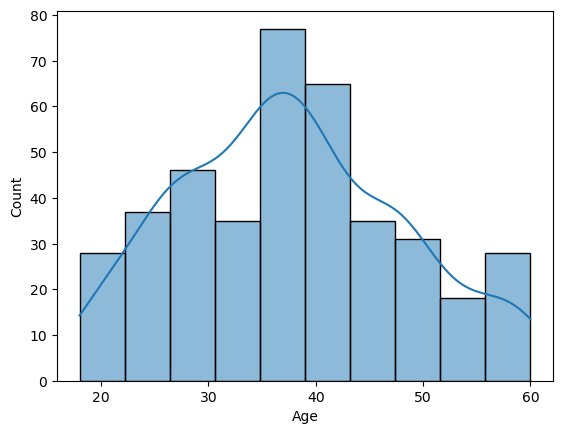

In [15]:
sns.histplot(data=df["Age"],kde=True)
plt.show()

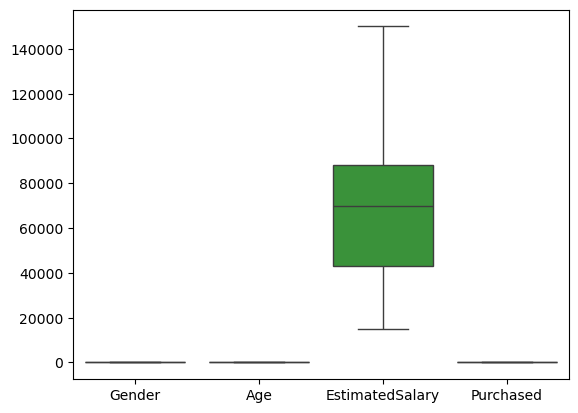

In [16]:
sns.boxplot(data=df)
plt.show()

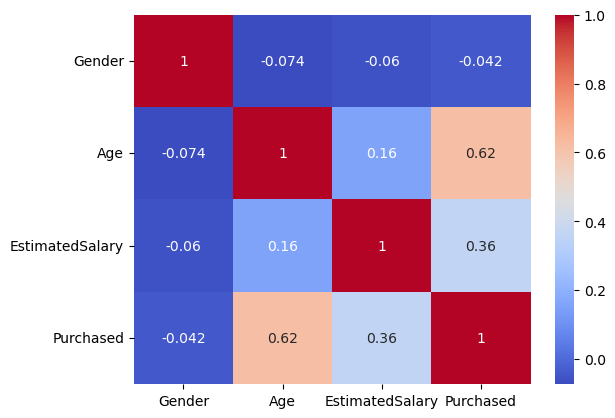

In [17]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [18]:
x=df.drop(columns=["Purchased"])
y=df["Purchased"]

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [20]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)

x_test_scaled=ss.transform(x_test)

In [21]:
model=LogisticRegression()

In [22]:
model.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
pred=model.predict(x_test_scaled)

0.9125
0.08750000000000002
0.8947368421052632
0.10526315789473684


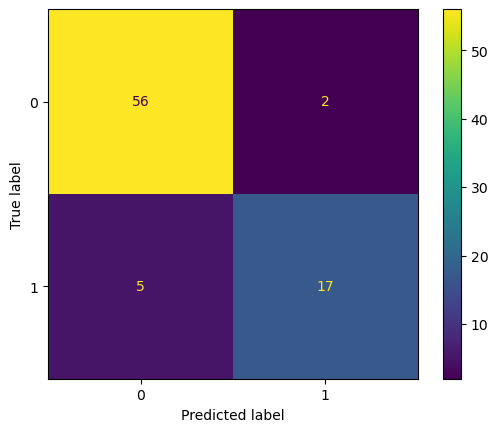

In [24]:
cm=confusion_matrix(y_test,pred)
display=ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
TP=cm[1][1]
FP=cm[0][1]
TN=cm[0][0]
FN=cm[1][0]

total=TP+FP+TN+FN

accuracy=(TP+TN)/total
error_rate=1-accuracy
precision=TP/(TP+FP)
recall=FP/(TP+FP)
print(accuracy)
print(error_rate)
print(precision)
print(recall)

In [25]:
a=accuracy_score(y_test,pred)
e=1-accuracy_score(y_test,pred)
p=precision_score(y_test,pred)
r=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
print(a)
print(e)
print(p)
print(f1)

0.9125
0.08750000000000002
0.8947368421052632
0.8292682926829268


In [26]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94        58
           1       0.89      0.77      0.83        22

    accuracy                           0.91        80
   macro avg       0.91      0.87      0.89        80
weighted avg       0.91      0.91      0.91        80



In [27]:
sample_input=[[1,60,42000]]
sample_input=ss.transform(sample_input)

output=model.predict(sample_input)
print(output[0])

1


/usr/lib/python3/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
